In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.preprocessing as prepoc
from sklearn.preprocessing import OneHotEncoder, StandardScaler
%matplotlib inline

### Loading data

In [2]:
data_dir = "../data/train.csv"
df = pd.read_csv(data_dir)

### Features that describe rooms of a house

- FullBath: number of full bathrooms located above above ground level
- HalfBath: number of half bathrooms located above above ground level
- BedroomAbvGr: number of bedrooms above ground level (does NOT include basement bedrooms)
- KitchenAbvGr: number of Kitchens above ground level
- KitchenQual: Kitchen quality
- TotRmsAbvGrd: total number of rooms above ground level (does not include bathrooms)

### Exploring the column values of FullBath

In [27]:
df.FullBath.describe()

count    1460.000000
mean        1.565068
std         0.550916
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: FullBath, dtype: float64

In [28]:
n_nan = df.FullBath.isna().sum().item()
print(f"Number of nans in FullBath: {n_nan}")

Number of nans in FullBath: 0


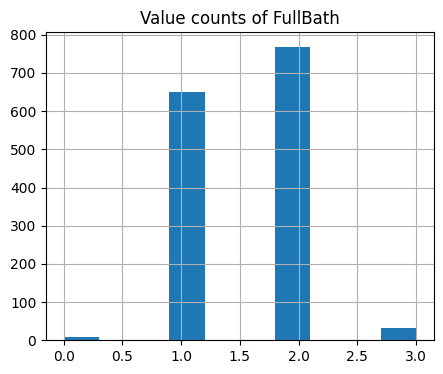

In [29]:
df.FullBath.hist(bins=10, figsize=(5, 4))
plt.title("Value counts of FullBath")
plt.show()

### Exploring the column values of HalfBath

In [30]:
df.HalfBath.describe()

count    1460.000000
mean        0.382877
std         0.502885
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         2.000000
Name: HalfBath, dtype: float64

In [31]:
n_nan = df.HalfBath.isna().sum().item()
print(f"Number of nans in HalfBath: {n_nan}")

Number of nans in FullBath: 0


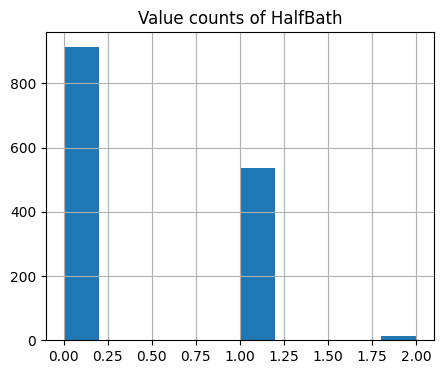

In [36]:
df.HalfBath.hist(bins=10, figsize=(5, 4))
plt.title("Value counts of HalfBath")
plt.show()

### Exploring the column values of BedroomAbvGr

In [37]:
df.BedroomAbvGr.describe()

count    1460.000000
mean        2.866438
std         0.815778
min         0.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         8.000000
Name: BedroomAbvGr, dtype: float64

In [38]:
n_nan = df.BedroomAbvGr.isna().sum().item()
print(f"Number of nans in BedroomAbvGr: {n_nan}")

Number of nans in BedroomAbvGr: 0


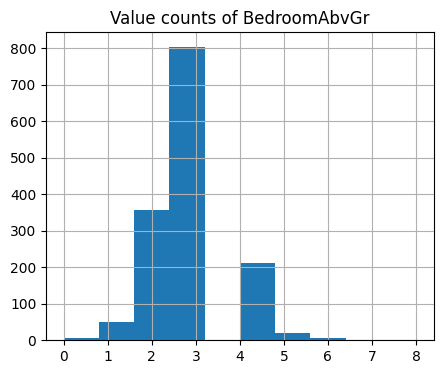

In [39]:
df.BedroomAbvGr.hist(bins=10, figsize=(5, 4))
plt.title("Value counts of BedroomAbvGr")
plt.show()

### Exploring the column values of KitchenAbvGr

In [40]:
df.KitchenAbvGr.describe()

count    1460.000000
mean        1.046575
std         0.220338
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: KitchenAbvGr, dtype: float64

In [41]:
n_nan = df.KitchenAbvGr.isna().sum().item()
print(f"Number of nans in KitchenAbvGr: {n_nan}")

Number of nans in KitchenAbvGr: 0


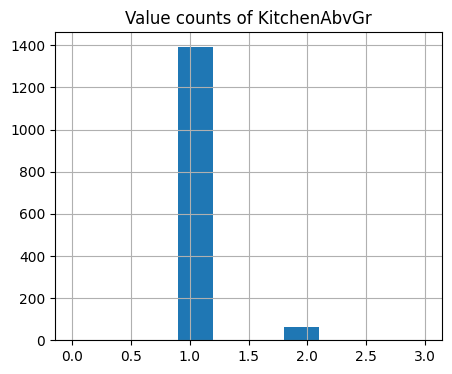

In [42]:
df.KitchenAbvGr.hist(bins=10, figsize=(5, 4))
plt.title("Value counts of KitchenAbvGr")
plt.show()

### Exploring the column values of KitchenQual

In [19]:
df.KitchenQual.unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [20]:
df.KitchenQual.value_counts()

KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

#### Checking how prices differentiate depending on the quality of a kitchen

In [21]:
ktch_ql_df = pd.concat([df[["KitchenQual"]], df[["SalePrice"]]], axis=1)

In [22]:
avg_price_per_ktch_ql = ktch_ql_df.groupby("KitchenQual")["SalePrice"].mean().round().reset_index()
avg_price_per_ktch_ql = avg_price_per_ktch_ql.sort_values("SalePrice")
avg_price_per_ktch_ql = avg_price_per_ktch_ql.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_ktch_ql

,KitchenQual,AvgSalePrice
1,Fa,105565.0
3,TA,139963.0
2,Gd,212116.0
0,Ex,328555.0


### Exploring the column values of TotRmsAbvGrd

In [24]:
df.TotRmsAbvGrd.describe()

count    1460.000000
mean        6.517808
std         1.625393
min         2.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        14.000000
Name: TotRmsAbvGrd, dtype: float64

In [25]:
n_nan = df.TotRmsAbvGrd.isna().sum().item()
print(f"Number of nans in TotRmsAbvGrd: {n_nan}")

Number of nans in TotRmsAbvGrd: 0


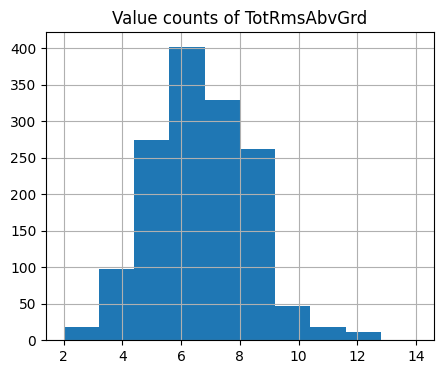

In [26]:
df.TotRmsAbvGrd.hist(bins=10, figsize=(5, 4))
plt.title("Value counts of TotRmsAbvGrd")
plt.show()